In [13]:
import pandas as pd
import matplotlib.pyplot as plt


xls = pd.ExcelFile("/content/Book1.xlsx")
df = xls.parse("Sheet1", skiprows=1)
df

,Unnamed: 0,Unnamed: 1,BCOM Index,Unnamed: 3,GC1 COMB Comdty
0,NaN,2015-04-20,101.1654,2015-04-20,1193.5
1,NaN,2015-04-21,100.7391,2015-04-21,1202.9
2,NaN,2015-04-22,100.6419,2015-04-22,1186.9
3,NaN,2015-04-23,101.6138,2015-04-23,1194.4
4,NaN,2015-04-24,101.5906,2015-04-24,1175.2
...,...,...,...,...,...
2515,NaN,2025-04-15,101.1614,2025-04-11,3222.2
2516,NaN,2025-04-16,102.4454,2025-04-14,3204.8
2517,NaN,2025-04-17,102.9124,2025-04-15,3218.7
2518,NaN,NaT,NaN,2025-04-16,3326.6


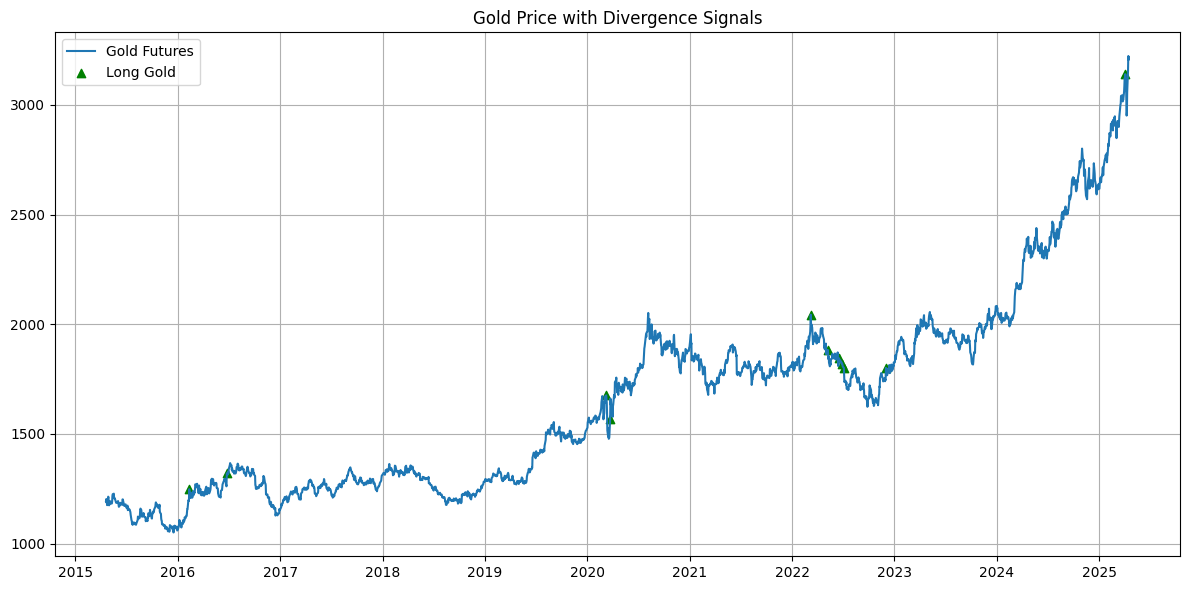

,Signal
Date,
2016-06-24,Long Gold
2020-03-09,Long Gold
2020-03-23,Long Gold
2022-03-09,Long Gold
2022-05-09,Long Gold
2022-06-17,Long Gold
2022-06-30,Long Gold
2022-07-05,Long Gold
2022-12-02,Long Gold


In [14]:
df.columns = ["_", "Date", "BCOM_Index", "Date2", "Gold_Futures"]

df = df[["Date", "BCOM_Index", "Gold_Futures"]]
df = df.dropna()


df["Date"] = pd.to_datetime(df["Date"])
df["BCOM_Index"] = pd.to_numeric(df["BCOM_Index"], errors="coerce")
df["Gold_Futures"] = pd.to_numeric(df["Gold_Futures"], errors="coerce")


df = df.sort_values("Date").set_index("Date")

# If Gold increases while BCOM drops → signal to long Gold

df["Gold_Return"] = df["Gold_Futures"].pct_change()
df["BCOM_Return"] = df["BCOM_Index"].pct_change()
df["Divergence"] = df["Gold_Return"] - df["BCOM_Return"]

#  when divergence > threshold → Long Gold
threshold = 0.04
df["Signal"] = df["Divergence"].apply(lambda x: "Long Gold" if x > threshold else "No Trade")

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Gold_Futures"], label="Gold Futures")
plt.title("Gold Price with Divergence Signals")
plt.grid(True)

long_signals = df[df["Signal"] == "Long Gold"]
plt.scatter(long_signals.index, long_signals["Gold_Futures"], color="green", marker="^", label="Long Gold")
plt.legend()
plt.tight_layout()
plt.show()

signals = df[df["Signal"] == "Long Gold"]["Signal"]
display(signals.tail(10))


In [4]:
from datetime import timedelta

In [15]:
gold_signals = df[df["Signal"] == "Long Gold"].copy()
gold_signals["Trade Date"] = gold_signals.index + timedelta(days=1)


trading_log_gold = pd.DataFrame({
    "Trade Date": gold_signals["Trade Date"],
    "Ticker": "Gold Futures",
    "Signal": "Long",
    "Notional": "TBD",
    "Comments": "Divergence strategy: Gold ↑ while BCOM ↓"
})

trading_log_gold.to_csv("Trading_Log_Gold.csv", index=False)


trading_log_gold.tail(10)


,Trade Date,Ticker,Signal,Notional,Comments
Date,,,,,
2016-06-24,2016-06-25,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2020-03-09,2020-03-10,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2020-03-23,2020-03-24,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2022-03-09,2022-03-10,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2022-05-09,2022-05-10,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2022-06-17,2022-06-18,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2022-06-30,2022-07-01,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2022-07-05,2022-07-06,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓
2022-12-02,2022-12-03,Gold Futures,Long,TBD,Divergence strategy: Gold ↑ while BCOM ↓


Backtest


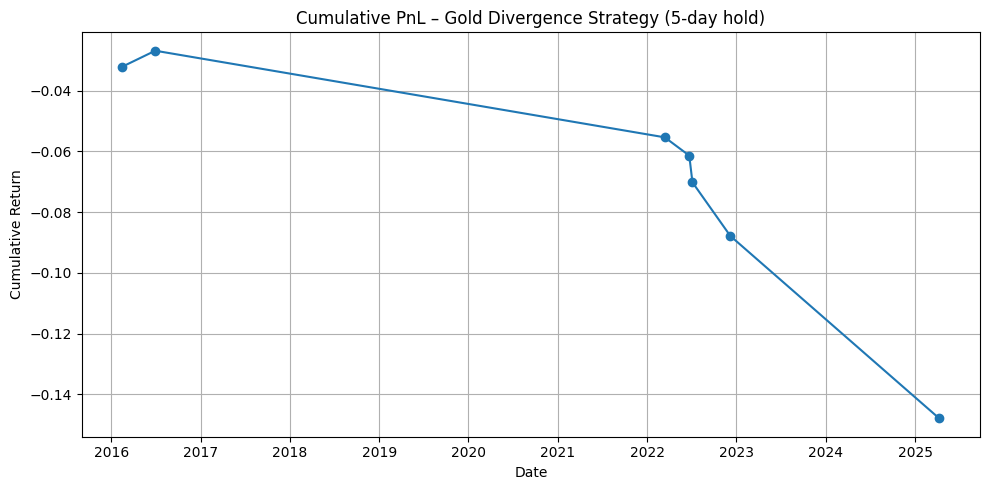

In [16]:

holding_period = 5


df = df.sort_index()

gold_signals = df[df["Signal"] == "Long Gold"].copy()

trades = []
for date in gold_signals.index:
    if date + pd.Timedelta(days=holding_period) in df.index:
        entry_price = df.loc[date, "Gold_Futures"]
        exit_price = df.loc[date + pd.Timedelta(days=holding_period), "Gold_Futures"]
        if pd.notna(entry_price) and pd.notna(exit_price):
            pnl = (exit_price - entry_price) / entry_price
            trades.append({
                "Entry Date": date,
                "Exit Date": date + pd.Timedelta(days=holding_period),
                "Entry Price": entry_price,
                "Exit Price": exit_price,
                "PnL": pnl
            })

# В таблицу
backtest_df = pd.DataFrame(trades)
backtest_df["Cumulative PnL"] = backtest_df["PnL"].cumsum()

# График
plt.figure(figsize=(10, 5))
plt.plot(backtest_df["Exit Date"], backtest_df["Cumulative PnL"], marker='o')
plt.title("Cumulative PnL – Gold Divergence Strategy (5-day hold)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()

# Статистика
summary = {
    "Number of Trades": len(backtest_df),
    "Average PnL": backtest_df["PnL"].mean(),
    "Median PnL": backtest_df["PnL"].median(),
    "Win Rate": (backtest_df["PnL"] > 0).mean() * 100,
    "Max PnL": backtest_df["PnL"].max(),
    "Min PnL": backtest_df["PnL"].min(),
    "Sharpe (naive)": backtest_df["PnL"].mean() / backtest_df["PnL"].std()
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])


In [17]:
summary_df

,Value
Number of Trades,7.000000
Average PnL,-0.021128
Median PnL,-0.017656
Win Rate,14.285714
Max PnL,0.005227
Min PnL,-0.060066
Sharpe (naive),-0.982032


In [18]:
display(backtest_df.tail(10))

,Entry Date,Exit Date,Entry Price,Exit Price,PnL,Cumulative PnL
0,2016-02-11,2016-02-16,1247.9,1207.9,-0.032054,-0.032054
1,2016-06-24,2016-06-29,1320.0,1326.9,0.005227,-0.026827
2,2022-03-09,2022-03-14,2043.3,1985.0,-0.028532,-0.055359
3,2022-06-17,2022-06-22,1845.7,1834.6,-0.006014,-0.061373
4,2022-06-30,2022-07-05,1817.5,1801.5,-0.008803,-0.070176
5,2022-12-02,2022-12-07,1801.1,1769.3,-0.017656,-0.087832
6,2025-04-04,2025-04-09,3139.9,2951.3,-0.060066,-0.147898


live logs

In [19]:

start_date = pd.Timestamp("2025-04-01")
end_date = pd.Timestamp("2025-04-30")


live_signals = df[
    (df["Signal"] == "Long Gold") &
    (df.index >= start_date) &
    (df.index <= end_date)
].copy()


if not live_signals.empty:
    live_signals["Trade Date"] = live_signals.index + pd.Timedelta(days=1)
    trading_log_live = pd.DataFrame({
        "Trade Date": live_signals["Trade Date"],
        "Ticker": "Gold Futures",
        "Signal": "Long",
        "Notional": "TBD",
        "Comments": "Live divergence signal (Gold ↑, BCOM ↓)"
    })


    live_log_path = "Trading_Log_Live_commodities.csv"
    trading_log_live.to_csv(live_log_path, index=False)
    live_log_status = f" {len(trading_log_live)} live signalsv"
else:
    trading_log_live = pd.DataFrame()
    live_log_status = " No  signals"

live_log_status, trading_log_live.tail(5)


(' 1 live signalsv',
            Trade Date        Ticker Signal Notional  \
 Date                                                  
 2025-04-04 2025-04-05  Gold Futures   Long      TBD   
 
                                            Comments  
 Date                                                 
 2025-04-04  Live divergence signal (Gold ↑, BCOM ↓)  )